# Employee Retention Analysis Using Unsupervised Learning

This notebook is split into seven sections:
1. Data Prep & EDA
2. K-Means Clustering
3. PCA for Visualization
4. K-Means Clustering (Round 2)
5. PCA for Visualization (Round 2)
6. EDA on Clusters
7. Make Recommendations

# Goal & Scope

**GOAL**: You are trying to better understand the company’s different segments of employees and how to increase employee retention within each segment.

**SCOPE**: Your task is to use a clustering technique to segment the employees, a dimensionality reduction technique to visualize the segments, and finally explore the clusters to make recommendations to increase retention.

## 1. Data Prep & EDA

### a. Data Prep: Check the data types

In [1]:
# read in the employee data
import pandas as pd
employees=pd.read_csv("../Data/employee_data.csv")
employees.head()

,EmployeeID,Age,Gender,DistanceFromHome,JobLevel,Department,MonthlyIncome,PerformanceRating,JobSatisfaction,Attrition
0,1001,41,Female,1,2,Sales,5993,3,4,Yes
1,1002,49,Male,8,2,Research & Development,5130,4,2,No
2,1004,37,Male,2,1,Research & Development,2090,3,3,Yes
3,1005,33,Female,3,1,Research & Development,2909,3,3,No
4,1007,27,Male,2,1,Research & Development,3468,3,2,No


In [2]:
# note the number of rows and columns
employees.shape

(1470, 10)

In [3]:
# view the data types of all the columns
employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   EmployeeID         1470 non-null   int64 
 1   Age                1470 non-null   int64 
 2   Gender             1470 non-null   object
 3   DistanceFromHome   1470 non-null   int64 
 4   JobLevel           1470 non-null   int64 
 5   Department         1470 non-null   object
 6   MonthlyIncome      1470 non-null   int64 
 7   PerformanceRating  1470 non-null   int64 
 8   JobSatisfaction    1470 non-null   int64 
 9   Attrition          1470 non-null   object
dtypes: int64(7), object(3)
memory usage: 115.0+ KB


In [4]:
# look at the numeric columns
employees.dtypes[employees.dtypes=="int64"]

EmployeeID           int64
Age                  int64
DistanceFromHome     int64
JobLevel             int64
MonthlyIncome        int64
PerformanceRating    int64
JobSatisfaction      int64
dtype: object

In [5]:
# look at the non-numeric columns
employees.dtypes[employees.dtypes!="int64"]

Gender        object
Department    object
Attrition     object
dtype: object

### b. Data Prep: Convert the data types

Use `np.where` and `pd.get_dummies` to create a DataFrame for modeling where all fields are numeric.

In [6]:
# create a copy of the dataframe
df = employees.copy()

In [7]:
# look at the gender values
df.Gender.value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

In [8]:
df.head()

,EmployeeID,Age,Gender,DistanceFromHome,JobLevel,Department,MonthlyIncome,PerformanceRating,JobSatisfaction,Attrition
0,1001,41,Female,1,2,Sales,5993,3,4,Yes
1,1002,49,Male,8,2,Research & Development,5130,4,2,No
2,1004,37,Male,2,1,Research & Development,2090,3,3,Yes
3,1005,33,Female,3,1,Research & Development,2909,3,3,No
4,1007,27,Male,2,1,Research & Development,3468,3,2,No


In [9]:
# change gender into a numeric field using np.where
import numpy as np

df.Gender = np.where(df.Gender == 'Female', 1, 0)
df.Gender.head()

0    1
1    0
2    0
3    1
4    0
Name: Gender, dtype: int64

In [10]:
# look at the attrition values
df.Attrition.value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [11]:
# change attrition to a numeric field using np.where
df.Attrition = np.where(df.Attrition== "No",0,1)
df.head()

,EmployeeID,Age,Gender,DistanceFromHome,JobLevel,Department,MonthlyIncome,PerformanceRating,JobSatisfaction,Attrition
0,1001,41,1,1,2,Sales,5993,3,4,1
1,1002,49,0,8,2,Research & Development,5130,4,2,0
2,1004,37,0,2,1,Research & Development,2090,3,3,1
3,1005,33,1,3,1,Research & Development,2909,3,3,0
4,1007,27,0,2,1,Research & Development,3468,3,2,0


In [12]:
# look at the department values
df.Department.value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

In [13]:
# change department to a numeric field via dummy variables
pd.get_dummies(df.Department).astype(int)

,Human Resources,Research & Development,Sales
0,0,0,1
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0
...,...,...,...
1465,0,1,0
1466,0,1,0
1467,0,1,0
1468,0,0,1


In [14]:
# attach the columns back on to the dataframe
data = pd.concat([df,pd.get_dummies(df.Department).astype(int)],axis=1)
data.head()

,EmployeeID,Age,Gender,DistanceFromHome,JobLevel,Department,MonthlyIncome,PerformanceRating,JobSatisfaction,Attrition,Human Resources,Research & Development,Sales
0,1001,41,1,1,2,Sales,5993,3,4,1,0,0,1
1,1002,49,0,8,2,Research & Development,5130,4,2,0,0,1,0
2,1004,37,0,2,1,Research & Development,2090,3,3,1,0,1,0
3,1005,33,1,3,1,Research & Development,2909,3,3,0,0,1,0
4,1007,27,0,2,1,Research & Development,3468,3,2,0,0,1,0


In [15]:
# view the cleaned dataframe
data = data.drop(columns=["Department"])

In [16]:
data.head()

,EmployeeID,Age,Gender,DistanceFromHome,JobLevel,MonthlyIncome,PerformanceRating,JobSatisfaction,Attrition,Human Resources,Research & Development,Sales
0,1001,41,1,1,2,5993,3,4,1,0,0,1
1,1002,49,0,8,2,5130,4,2,0,0,1,0
2,1004,37,0,2,1,2090,3,3,1,0,1,0
3,1005,33,1,3,1,2909,3,3,0,0,1,0
4,1007,27,0,2,1,3468,3,2,0,0,1,0


In [17]:
# note the number of rows and columns
data.shape

(1470, 12)

### c. EDA

Our goal is to find the different types of employees at the company and take a look at their attrition (whether they end up leaving or not).

In [18]:
# what is the overall attrition for all employees in the data aka what percent of employees leave the company?
data.Attrition.mean() # 16 % of employees leave the company

np.float64(0.16122448979591836)

In [19]:
# create a summary table to show the mean of each column for employees who stay vs leave - what are your takeaways?
data.groupby("Attrition").mean()

,EmployeeID,Age,Gender,DistanceFromHome,JobLevel,MonthlyIncome,PerformanceRating,JobSatisfaction,Human Resources,Research & Development,Sales
Attrition,,,,,,,,,,,
0,2027.656123,37.561233,0.406326,8.915653,2.145985,6832.739659,3.153285,2.778589,0.041363,0.671533,0.287105
1,2010.345992,33.607595,0.367089,10.632911,1.637131,4787.092827,3.156118,2.468354,0.050633,0.561181,0.388186


### d. Data Prep: Remove the Attrition and ID Columns

Exclude the attrition column (to be overlayed onto our clusters later on) and the ID column.

In [20]:
# create a new dataframe without the attrition column for us to model on
df_final = data.drop(columns=["EmployeeID","Attrition"])
df_final.head()

,Age,Gender,DistanceFromHome,JobLevel,MonthlyIncome,PerformanceRating,JobSatisfaction,Human Resources,Research & Development,Sales
0,41,1,1,2,5993,3,4,0,0,1
1,49,0,8,2,5130,4,2,0,1,0
2,37,0,2,1,2090,3,3,0,1,0
3,33,1,3,1,2909,3,3,0,1,0
4,27,0,2,1,3468,3,2,0,1,0


In [22]:
# note the number of rows and columns in the dataframe
df_final.shape

(1470, 10)

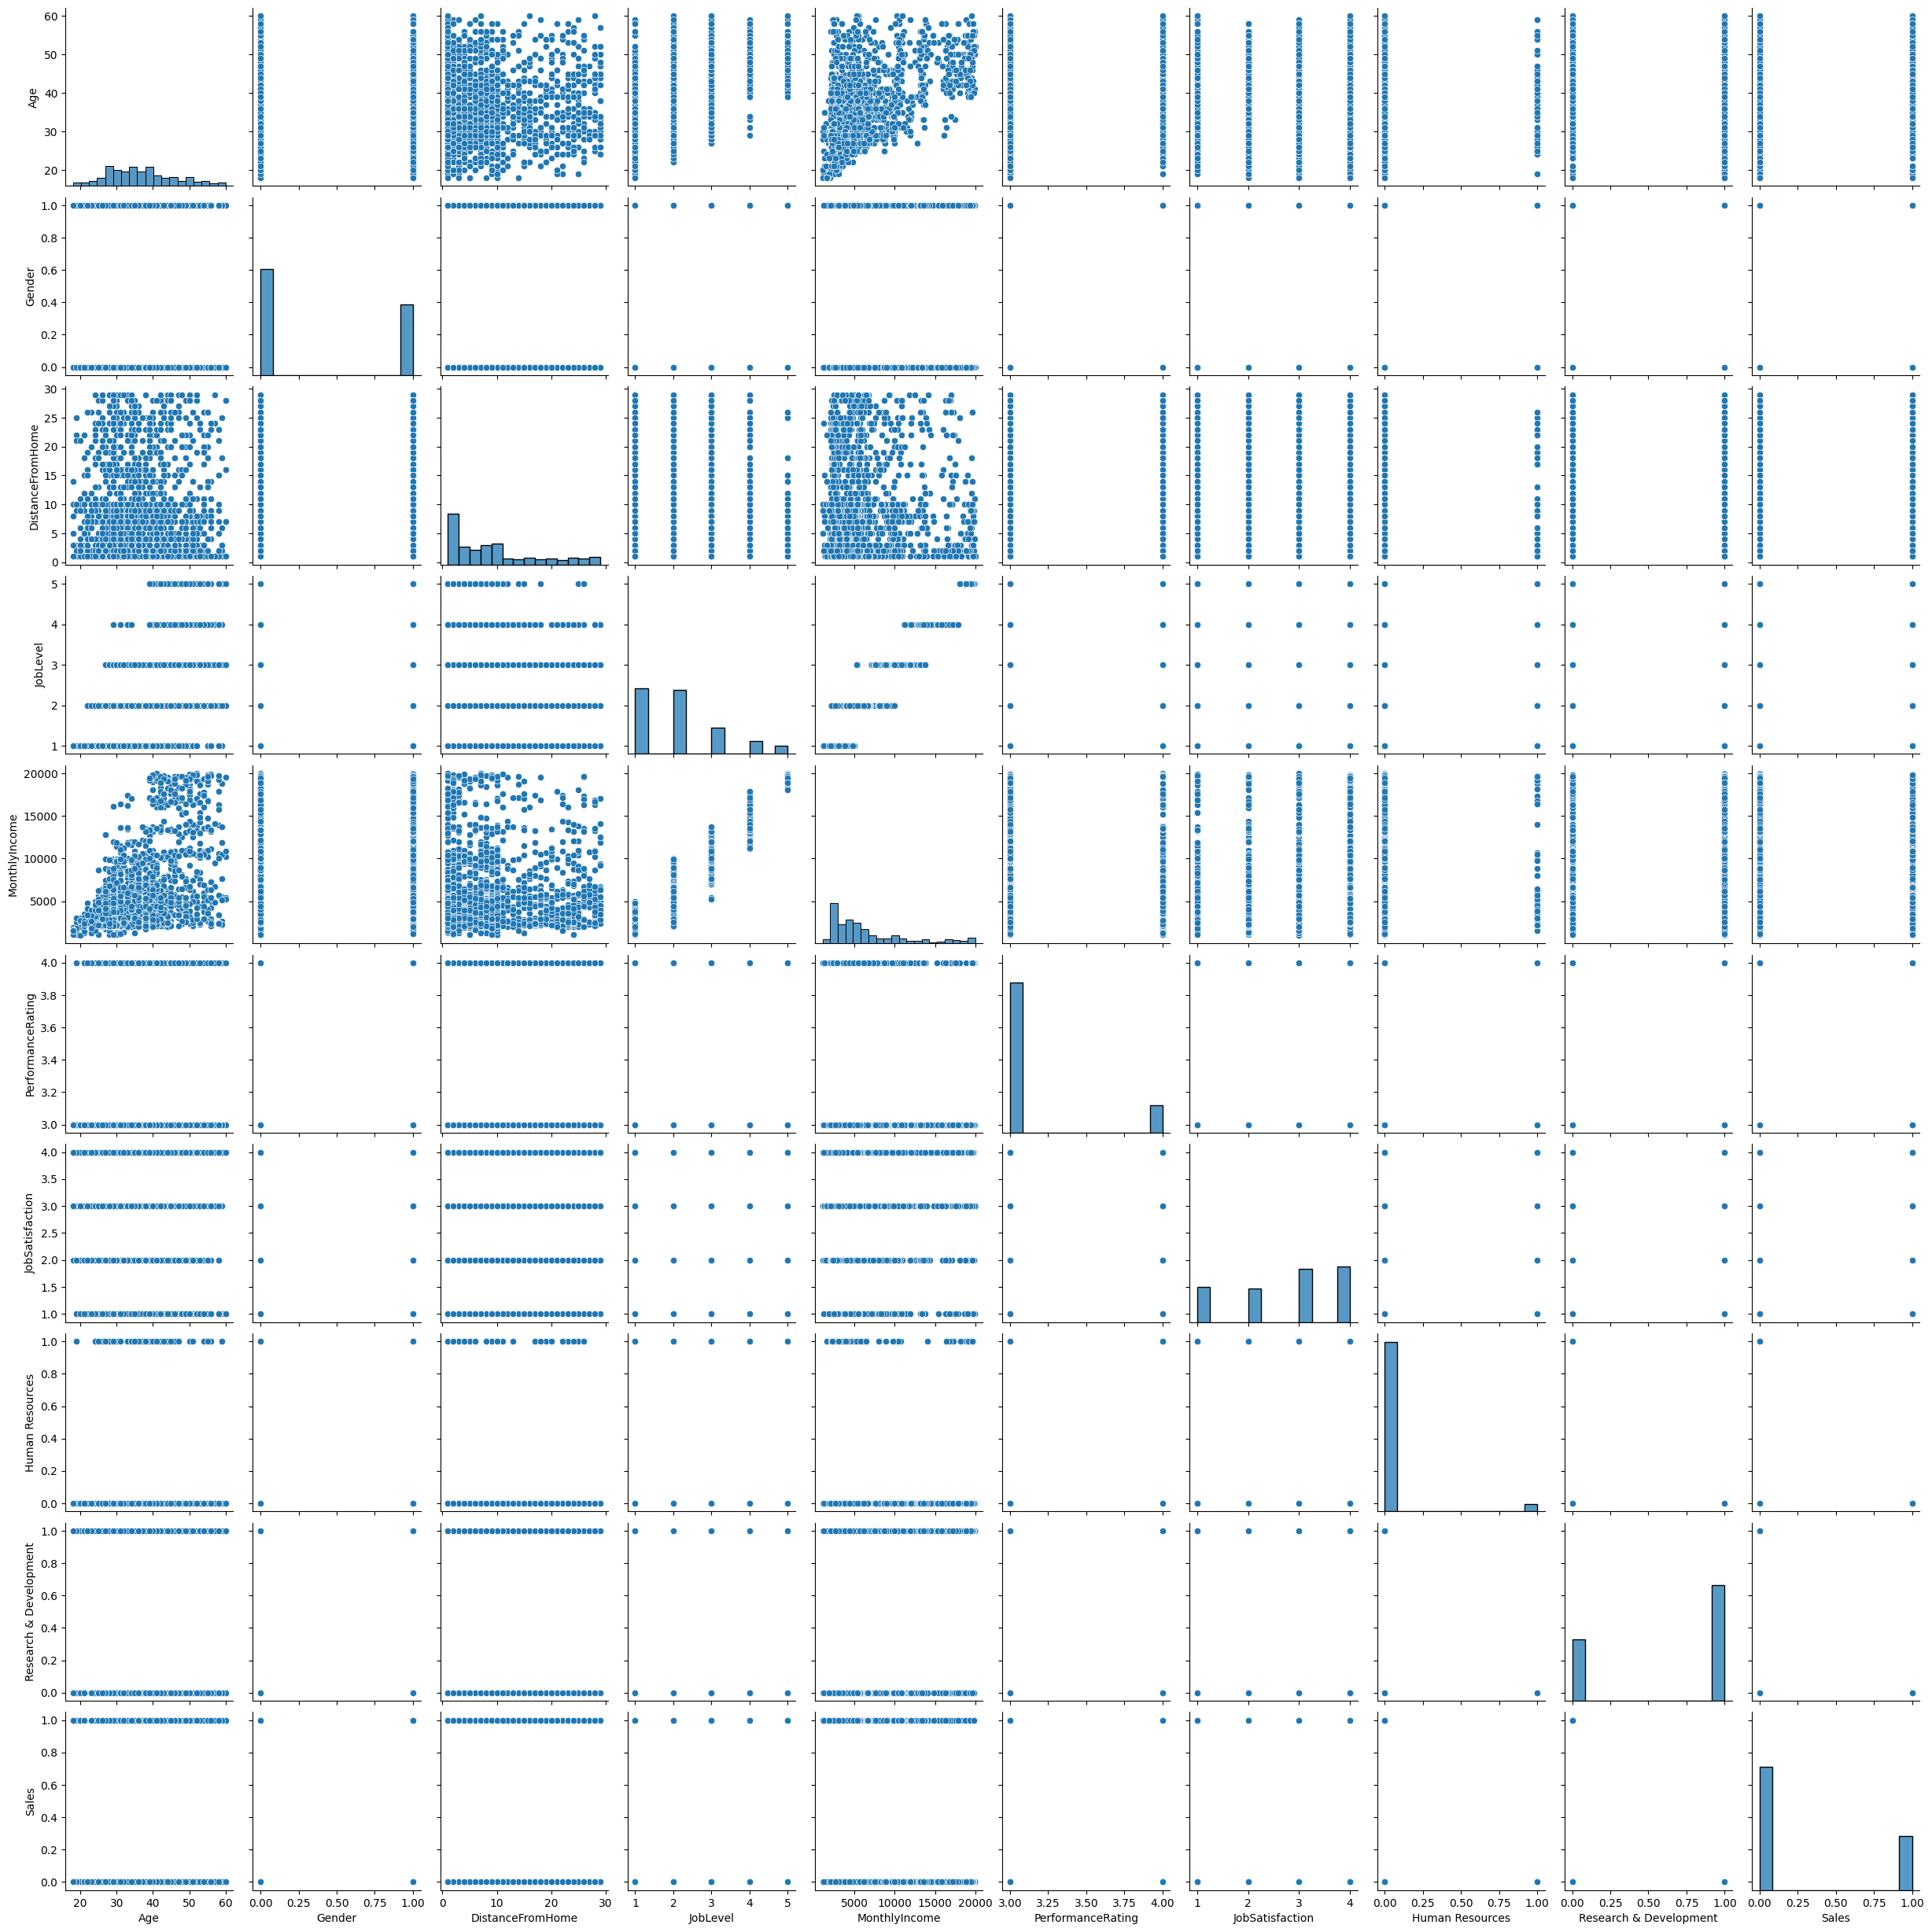

In [23]:
# create a pair plot comparing all the columns of the dataframe - what observations do you notice?
import seaborn as sns
sns.pairplot(df_final)

## 2. K-Means Clustering

Let's segment the employees using K-Means clustering.

### a. Standardize the data

In [88]:
# scale the data using standardization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
df_scaled=sc.fit_transform(df_final)
df_scaled=pd.DataFrame(df_scaled,columns=df_final.columns)
df_scaled.head()

,Age,Gender,DistanceFromHome,JobLevel,MonthlyIncome,PerformanceRating,JobSatisfaction,Human Resources,Research & Development,Sales
0,0.446350,1.224745,-1.010909,-0.057788,-0.108350,-0.426230,1.153254,-0.211604,-1.374051,1.515244
1,1.322365,-0.816497,-0.147150,-0.057788,-0.291719,2.346151,-0.660853,-0.211604,0.727775,-0.659960
2,0.008343,-0.816497,-0.887515,-0.961486,-0.937654,-0.426230,0.246200,-0.211604,0.727775,-0.659960
3,-0.429664,1.224745,-0.764121,-0.961486,-0.763634,-0.426230,0.246200,-0.211604,0.727775,-0.659960
4,-1.086676,-0.816497,-0.887515,-0.961486,-0.644858,-0.426230,-0.660853,-0.211604,0.727775,-0.659960


In [89]:
# double check that all the column means are 0 and standard deviations are 1
df_scaled.describe().round(2)

,Age,Gender,DistanceFromHome,JobLevel,MonthlyIncome,PerformanceRating,JobSatisfaction,Human Resources,Research & Development,Sales
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.07,-0.82,-1.01,-0.96,-1.17,-0.43,-1.57,-0.21,-1.37,-0.66
25%,-0.76,-0.82,-0.89,-0.96,-0.76,-0.43,-0.66,-0.21,-1.37,-0.66
50%,-0.10,-0.82,-0.27,-0.06,-0.34,-0.43,0.25,-0.21,0.73,-0.66
75%,0.67,1.22,0.59,0.85,0.40,-0.43,1.15,-0.21,0.73,1.52
max,2.53,1.22,2.44,2.65,2.87,2.35,1.15,4.73,0.73,1.52


### b. Write a loop to fit models with 2 to 15 clusters and record the inertia and silhouette scores

In [97]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_values=[]
silhouette_values=[]

for i in range(2,16):
    kmeans = KMeans(n_clusters=i,n_init=10,random_state=42)
    kmeans.fit(df_scaled)

    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(df_scaled,kmeans.labels_,metric="euclidean",sample_size=None))
    

Text(0.5, 1.0, 'Number of Clusters vs. Inertia')

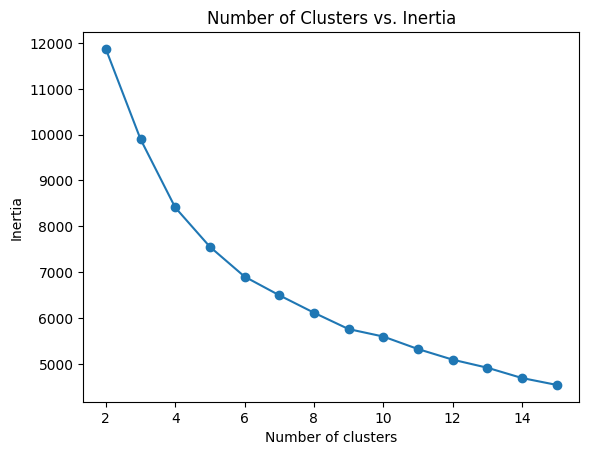

In [98]:
# plot the inertia values
import matplotlib.pyplot as plt

inertia_series = pd.Series(inertia_values,index=range(2,16))

inertia_series.plot(marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Number of Clusters vs. Inertia")

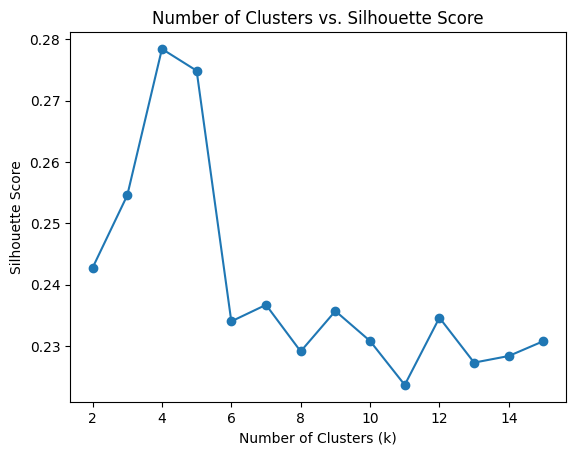

In [99]:
# plot the silhouette scores
silhouette_series = pd.Series(silhouette_values, index=range(2, 16))

# plot the data
silhouette_series.plot(marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Number of Clusters vs. Silhouette Score");

### c. Identify a k value that looks like an elbow on the inertia plot and has a high silhouette score

In [100]:
# fit a kmeans model for the k value that you identified
kmean4 = KMeans(n_clusters=4,n_init=10,random_state=42)
kmean4.fit(df_scaled)

,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [103]:
# find the number of employees in each cluster
from collections import Counter
Counter(kmean4.labels_)

Counter({np.int32(0): 747,
         np.int32(1): 407,
         np.int32(2): 253,
         np.int32(3): 63})

In [105]:
# create a heat map of the cluster centers
cluster_centers = kmean4.cluster_centers_
cluster_centers_df = pd.DataFrame(cluster_centers,columns=df_scaled.columns)
cluster_centers_df.head()

,Age,Gender,DistanceFromHome,JobLevel,MonthlyIncome,PerformanceRating,JobSatisfaction,Human Resources,Research & Development,Sales
0,-0.247161,-0.032245,0.005648,-0.544115,-0.534532,0.026555,-0.001509,-0.211604,0.727775,-0.659960
1,-0.170573,0.031095,0.041125,-0.006719,-0.102924,-0.051584,0.034480,-0.211604,-1.374051,1.515244
2,0.980010,0.087136,-0.067651,1.624593,1.735798,0.012091,-0.022689,-0.211604,0.403778,-0.324652
3,0.096987,-0.168483,-0.060970,-0.029099,0.032207,-0.030176,-0.113742,4.725816,-1.374051,-0.659960


<Axes: >

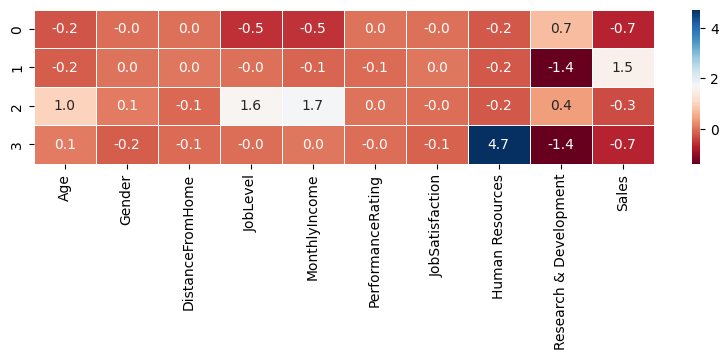

In [106]:
plt.figure(figsize=(10,2))
sns.heatmap(cluster_centers_df,cmap="RdBu",annot=True,fmt=".1f", linewidths=.5)

In [31]:
# interpret the clusters

In [107]:
# cluster 0: junior,research and dev employees
# cluster 1: sales employees
# cluster 2: senior employees
# cluster 3: HR employees

## 3. PCA

Let's visualize the data using PCA.

### a. Fit a PCA Model with 2 components for visualization

In [109]:
# fit a PCA model with 2 components
from sklearn.decomposition import PCA
pca4 = PCA(n_components=2)
pca4.fit(df_scaled)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [110]:
# view the explained variance ratio
pca4.explained_variance_ratio_

array([0.23793893, 0.18883434])

In [112]:
# view the components

In [113]:
df_scaled.columns

Index(['Age', 'Gender', 'DistanceFromHome', 'JobLevel', 'MonthlyIncome',
       'PerformanceRating', 'JobSatisfaction', 'Human Resources',
       'Research & Development', 'Sales'],
      dtype='object')

In [111]:
pca4.components_

array([[ 0.43287352,  0.04877625, -0.00285089,  0.60509274,  0.59445012,
        -0.02556521, -0.00472736,  0.02964393, -0.21392918,  0.20833797],
       [ 0.21384802, -0.00840873, -0.01653328,  0.14533326,  0.17730123,
         0.04153184, -0.01140416, -0.11374447,  0.67887246, -0.65246219]])

* component 1 : higher age,job level,monthly income=more senior
* component 2 : lower = sales and higher = research

### b. Overlay the K-Means cluster colors

In [116]:
# transform the data
df_transformed_4 = pca4.transform(df_scaled)
pc_df_4 = pd.DataFrame(df_transformed_4,columns=['PC-1','PC-2'])
pc_df_4.head()

,PC-1,PC-2
0,0.765263,-1.853973
1,-0.031684,1.285674
2,-1.462588,0.645564
3,-1.449531,0.563547
4,-1.758252,0.473654


Text(0, 0.5, '<------Sales   Research--------->')

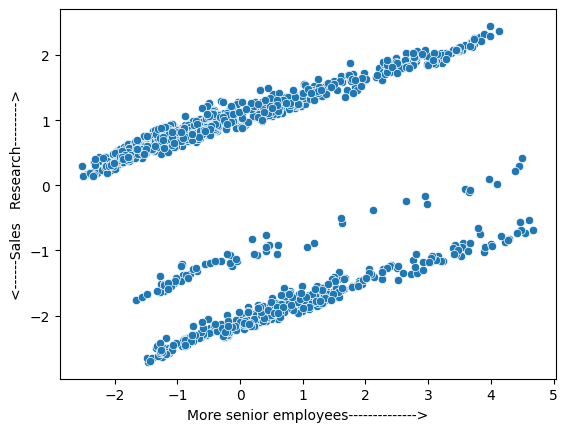

In [117]:
# plot the data
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x="PC-1",y="PC-2",data=pc_df_4)
plt.xlabel("More senior employees-------------->")
plt.ylabel("<------Sales   Research--------->")

Text(0, 0.5, '<------Sales   Research--------->')

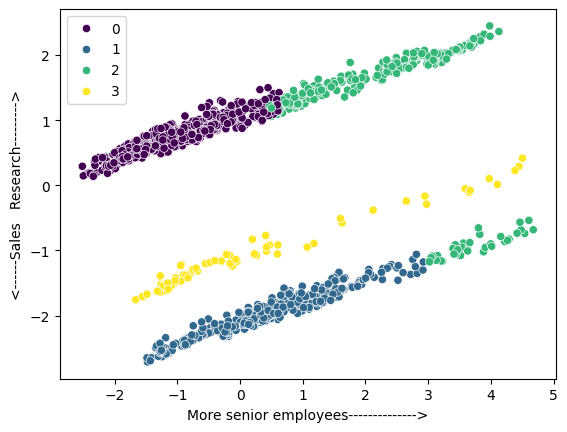

In [119]:
# overlay the kmeans clusters 
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x="PC-1",y="PC-2",data=pc_df_4,hue=kmean4.labels_,palette="viridis")
plt.xlabel("More senior employees-------------->")
plt.ylabel("<------Sales   Research--------->")

### c. Overlay the Department colors instead

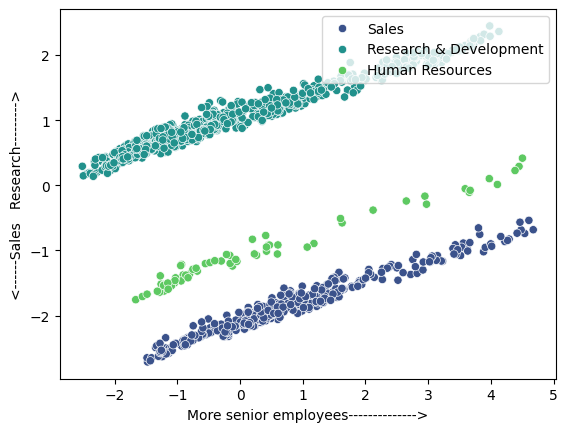

In [122]:
# overlay the department colors (hint: set the hue to be the department column)
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x="PC-1",y="PC-2",data=pc_df_4,hue=df.Department,palette="viridis")
plt.xlabel("More senior employees-------------->")
plt.ylabel("<------Sales   Research--------->")

plt.legend(loc="upper right")

## 4. K-Means Clustering: Round 2

Since the departments seemed to dominate the visualization, let's exclude them and try fitting more K-Means models.

### a. Create a new dataframe without the Departments

In [124]:
# create a new dataframe that excludes the three department columns from the scaled dataframe
df_scaled_v2 = df_scaled.iloc[:,:7]
df_scaled_v2.head()

,Age,Gender,DistanceFromHome,JobLevel,MonthlyIncome,PerformanceRating,JobSatisfaction
0,0.446350,1.224745,-1.010909,-0.057788,-0.108350,-0.426230,1.153254
1,1.322365,-0.816497,-0.147150,-0.057788,-0.291719,2.346151,-0.660853
2,0.008343,-0.816497,-0.887515,-0.961486,-0.937654,-0.426230,0.246200
3,-0.429664,1.224745,-0.764121,-0.961486,-0.763634,-0.426230,0.246200
4,-1.086676,-0.816497,-0.887515,-0.961486,-0.644858,-0.426230,-0.660853


### b. Write a loop to fit models with 2 to 15 clusters and record the inertia and silhouette scores

In [125]:
# write a loop to fit models with 2 to 15 clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_values=[]
silhouette_values=[]

for i in range(2,16):
    kmeans = KMeans(n_clusters=i,n_init=10,random_state=42)
    kmeans.fit(df_scaled_v2)

    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(df_scaled_v2,kmeans.labels_,metric="euclidean",sample_size=None))

Text(0.5, 1.0, 'Number of Clusters vs. Inertia')

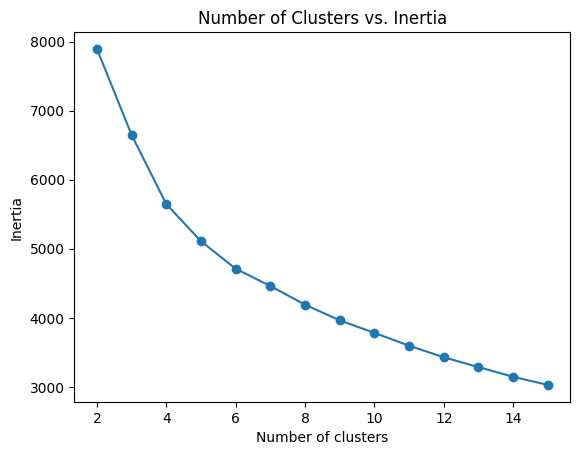

In [126]:
# plot the inertia values
import matplotlib.pyplot as plt

inertia_series = pd.Series(inertia_values,index=range(2,16))

inertia_series.plot(marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Number of Clusters vs. Inertia")

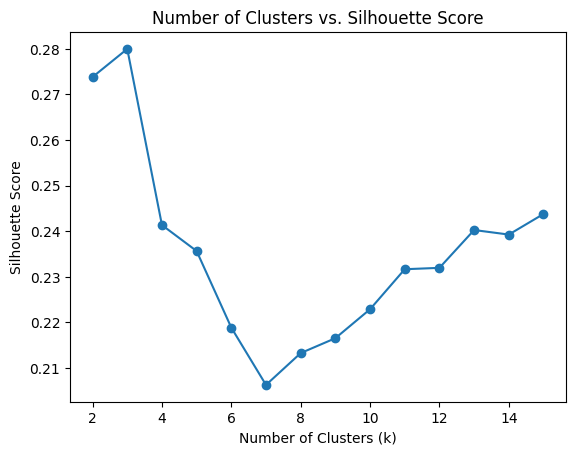

In [127]:
# plot the silhouette scores
silhouette_series = pd.Series(silhouette_values, index=range(2, 16))

# plot the data
silhouette_series.plot(marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Number of Clusters vs. Silhouette Score");

### c. Identify a few k values that looks like an elbow on the inertia plot and have a high silhouette score

#### i. k = [some value]

In [138]:
# fit a kmeans model for the k value that you identified
kmean3 = KMeans(n_clusters=3,n_init=10,random_state=42)
kmean3.fit(df_scaled_v2)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [139]:
# find the number of employees in each cluster
Counter(kmean3.labels_)

Counter({np.int32(1): 988, np.int32(2): 282, np.int32(0): 200})

In [140]:
# create a heat map of the cluster centers
cluster_centers_3 = kmean3.cluster_centers_
cluster_centers_3_df = pd.DataFrame(cluster_centers_3,columns=df_scaled_v2.columns)
cluster_centers_3_df

,Age,Gender,DistanceFromHome,JobLevel,MonthlyIncome,PerformanceRating,JobSatisfaction
0,-0.166860,0.010206,0.064471,-0.310823,-0.328330,2.346151,-0.016845
1,-0.270732,-0.023140,-0.010517,-0.401705,-0.422780,-0.426230,0.003830
2,1.066861,0.073832,-0.008878,1.627835,1.714087,-0.170620,-0.001470


<Axes: >

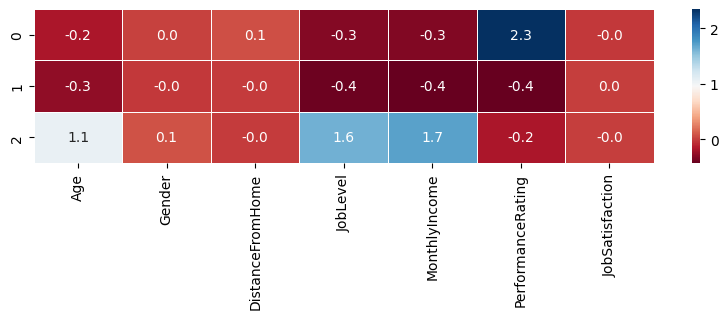

In [141]:
# interpret the clusters
plt.figure(figsize=(10,2))
sns.heatmap(cluster_centers_3_df,cmap="RdBu",annot=True,fmt=".1f", linewidths=.5)

In [142]:
# cluster 0 : High performing employees
# cluster 1 : low performing junior employees
# cluster 2 . senior employees

#### ii. k = [another value]

In [145]:
# fit a kmeans model for the k value that you identified
kmean4_v2 = KMeans(n_clusters=4,n_init=10,random_state=42)
kmean4_v2.fit(df_scaled_v2)

,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [146]:
# find the number of employees in each cluster
Counter(kmean4_v2.labels_)

Counter({np.int32(2): 616,
         np.int32(0): 405,
         np.int32(1): 249,
         np.int32(3): 200})

In [147]:
cluster_centers_4 = kmean4_v2.cluster_centers_
cluster_centers_4_df = pd.DataFrame(cluster_centers_4,columns=df_scaled_v2.columns)
cluster_centers_4_df

,Age,Gender,DistanceFromHome,JobLevel,MonthlyIncome,PerformanceRating,JobSatisfaction
0,-0.216879,1.224745,-0.037161,-0.318856,-0.355171,-0.426230,-0.015837
1,1.178562,0.019675,-0.005420,1.731464,1.838692,-0.136744,-0.008795
2,-0.279633,-0.816497,0.005691,-0.389339,-0.403124,-0.426230,0.019437
3,-0.166860,0.010206,0.064471,-0.310823,-0.328330,2.346151,-0.016845


<Axes: >

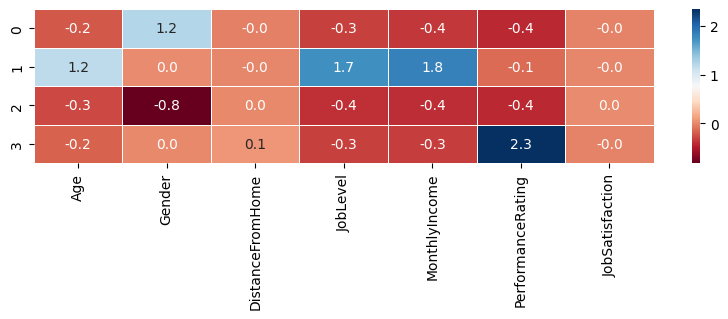

In [148]:
plt.figure(figsize=(10,2))
sns.heatmap(cluster_centers_4_df,cmap="RdBu",annot=True,fmt=".1f", linewidths=.5)

In [51]:
# create a heat map of the cluster centers

In [149]:
# interpret the clusters
# cluster 0 : female employees
# cluster 1 : senior employees
# cluster 2 : male employees
# cluster 4 : high performing employees

#### iii. k = [another value]

In [150]:
# fit a kmeans model for the k value that you identified
kmean6 = KMeans(n_clusters=6,n_init=10,random_state=42)
kmean6.fit(df_scaled_v2)

,n_clusters,6
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [151]:
# find the number of employees in each cluster
Counter(kmean6.labels_)

Counter({np.int32(3): 349,
         np.int32(0): 304,
         np.int32(4): 219,
         np.int32(5): 201,
         np.int32(1): 200,
         np.int32(2): 197})

In [152]:
cluster_centers_6 = kmean6.cluster_centers_
cluster_centers_6_df = pd.DataFrame(cluster_centers_6,columns=df_scaled_v2.columns)
cluster_centers_6_df

,Age,Gender,DistanceFromHome,JobLevel,MonthlyIncome,PerformanceRating,JobSatisfaction
0,-0.253885,-0.816497,-0.461318,-0.372893,-0.359236,-0.426230,0.726580
1,-0.166860,0.010206,0.064471,-0.310823,-0.328330,2.346151,-0.016845
2,-0.101159,-0.174075,1.705016,-0.222930,-0.284081,-0.426230,0.062027
3,-0.218505,1.224745,-0.346560,-0.327085,-0.361583,-0.426230,0.004493
4,1.214863,0.078294,-0.089115,1.852772,1.980065,-0.097089,0.010118
5,-0.295102,-0.816497,-0.338687,-0.359020,-0.381116,-0.426230,-1.161763


<Axes: >

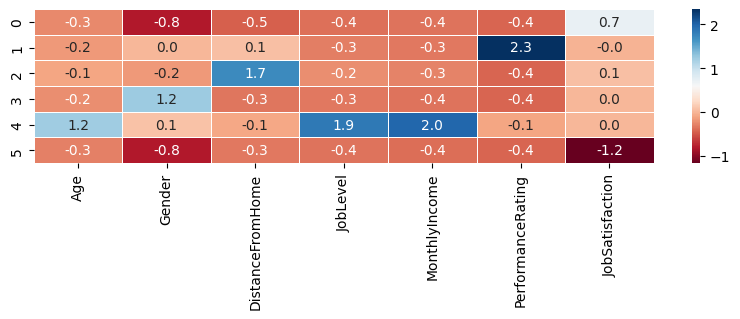

In [153]:
# create a heat map of the cluster centers
plt.figure(figsize=(10,2))
sns.heatmap(cluster_centers_6_df,cmap="RdBu",annot=True,fmt=".1f", linewidths=.5)

In [154]:
# Intrepretation

# cluster 0 : Men employees who likes thier job
# cluster 1 : Highly performing employees
# cluster 2 : long commuters (stays far from company)
# cluster 3 : womens
# cluster 4 : senior employees
# cluster 5 : Men employees who dislikes their job

cluster_mapping = { 0 : "Men employees who likes thier job",
                  1:"Highly performing employees",
                  2:"long commuters (stays far from company)",
                  3:"womens",
                  4:"senior employees",
                  5:" Men employees who dislikes their job"}

## 5. PCA: Round 2

Let's visualize the data (without Departments) using PCA.

### a. Fit a PCA Model with 2 components for visualization

In [155]:
# fit a PCA model with 2 components
pca2 = PCA(n_components=2)
pca2.fit(df_scaled_v2)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [156]:
# view the explained variance ratio
pca2.explained_variance_ratio_

array([0.33354222, 0.14850324])

In [157]:
# view the components
pca2.components_

array([[ 0.47124275,  0.0460627 , -0.00629691,  0.62393147,  0.62140377,
        -0.01687984, -0.00712661],
       [ 0.01896906,  0.58615904,  0.41405416, -0.01838822, -0.02778096,
         0.4833175 , -0.49991119]])

In [158]:
# view the columns
df_scaled_v2.columns

Index(['Age', 'Gender', 'DistanceFromHome', 'JobLevel', 'MonthlyIncome',
       'PerformanceRating', 'JobSatisfaction'],
      dtype='object')

# interpret the components
Interpret the components:
* Component 1: higher age, job level, monthly income = more senior
* Component 2: <-- happy in job | women, longer commute, higher perfomring -->

### b. Overlay the K-Means cluster colors

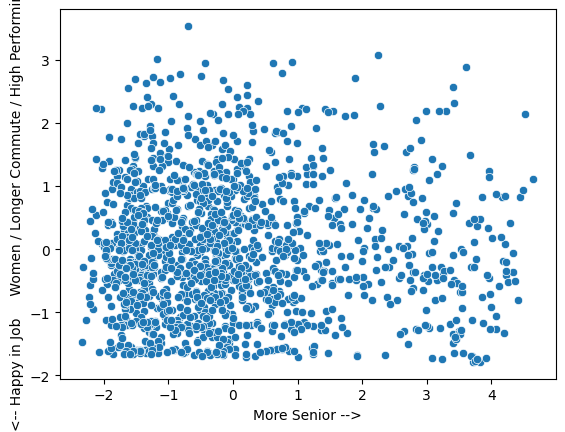

In [161]:
# transform the data
pc_new_2=pca2.transform(df_scaled_v2)
pc_new_2_df = pd.DataFrame(pc_new_2,columns=["PC1","PC2"])

sns.scatterplot(x='PC1', y='PC2', data=pc_new_2_df)
plt.xlabel('More Senior -->')
plt.ylabel('<-- Happy in Job     Women / Longer Commute / High Performing -->');

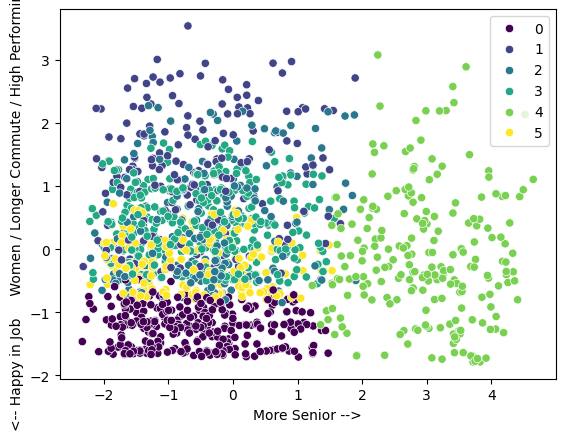

In [165]:
# overlay the kmeans clusters (choose your favorite k-means model from the previous section)
sns.scatterplot(x='PC1', y='PC2', data=pc_new_2_df,hue=kmean6.labels_,palette="viridis")
plt.xlabel('More Senior -->')
plt.ylabel('<-- Happy in Job     Women / Longer Commute / High Performing -->');

In [166]:
# fit a PCA model with 3 components
pca3_v2 = PCA(n_components=3)
pca3_v2.fit(df_scaled_v2)

,n_components,3
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [167]:
# view the explained variance ratio
pca3_v2.explained_variance_ratio_ 

array([0.33354222, 0.14850324, 0.14578114])

In [168]:
# view the components
pca3_v2.components_

array([[ 0.47124275,  0.0460627 , -0.00629691,  0.62393147,  0.62140377,
        -0.01687984, -0.00712661],
       [ 0.01896906,  0.58615904,  0.41405416, -0.01838822, -0.02778096,
         0.4833175 , -0.49991119],
       [ 0.02702996, -0.36313603,  0.55488385,  0.02159616,  0.01065236,
         0.52050007,  0.53666127]])

In [169]:
# view the columns
df_scaled_v2.columns

Index(['Age', 'Gender', 'DistanceFromHome', 'JobLevel', 'MonthlyIncome',
       'PerformanceRating', 'JobSatisfaction'],
      dtype='object')

# interpret the components
Interpret the components:
* Component 1: higher age, job level, monthly income = more senior
* Component 2: <-- happy in job | women, longer commute, higher perfomring -->
* Component 3: longer commute, higher performance, happy in job

In [172]:
# transform the data
df_scaled_transformed3_v2 = pd.DataFrame(pca3_v2.transform(df_scaled_v2), columns=['PC1', 'PC2', 'PC3'])
df_scaled_transformed3_v2.head()

,PC1,PC2,PC3
0,0.168712,-0.470665,-0.598970
1,0.334248,0.959030,1.112754
2,-1.205213,-1.131272,-0.316222
3,-1.210236,0.103169,-0.998987
4,-1.532824,-0.706731,-0.829482


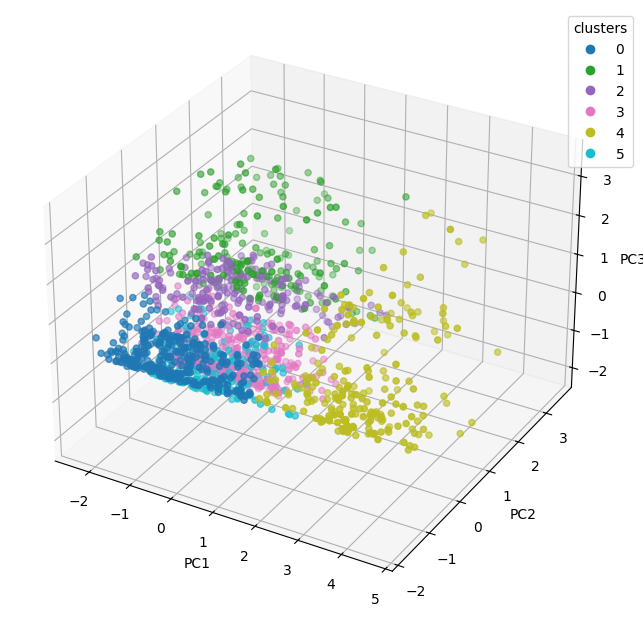

In [175]:
# create a 3d scatter plot
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# combine the data and cluster labels
cluster_labels = pd.Series(kmean6.labels_, name='cluster')

# create a clean dataframe
df_clean = pd.concat([df_scaled_transformed3_v2, cluster_labels], axis=1)

# create a 3d scatter plot
fig = plt.figure(figsize=(8, 6))
ax = Axes3D(fig)
fig.add_axes(ax)

# specify the data and labels
sc = ax.scatter(df_clean['PC1'], df_clean['PC2'], df_clean['PC3'],
                c=df_clean['cluster'], cmap='tab10')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

# add a legend
plt.legend(*sc.legend_elements(), title='clusters',
           bbox_to_anchor=(1.05, 1));

## 6. EDA on Clusters

### a. Confirm the 6 clusters

In [176]:
# fit a kmeans model with 6 clusters
kmean6

,n_clusters,6
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [177]:
# view the cluster labels
kmean6.labels_

array([3, 1, 0, ..., 1, 5, 0], shape=(1470,), dtype=int32)

### b. Create a dataframe with the cluster labels and names

In [180]:
# create a dataframe with two columns - one of the label and another of the cluster name
clusters = pd.DataFrame(kmean6.labels_,columns=['Cluster'])
clusters.head()
# create a mapping for the cluster names
cluster_mapping = {
                    0 : "Men employees who likes thier job",
                    1 :"Highly performing employees",
                    2 :"long commuters (stays far from company)",
                    3 :"womens",
                    4 :"senior employees",
                    5 :"Men employees who dislikes their job"
                  }
# combine the labels and names into a single dataframe
clusters["Cluster_name"] = clusters["Cluster"].map(cluster_mapping)
clusters.head()

,Cluster,Cluster_name
0,3,womens
1,1,Highly performing employees
2,0,Men employees who likes thier job
3,3,womens
4,5,Men employees who dislikes their job


### c. View the attrition rates for each cluster

In [181]:
# combine the clusters and attrition data
clusters = pd.concat([clusters,df.Attrition],axis=1)
clusters.head()

,Cluster,Cluster_name,Attrition
0,3,womens,1
1,1,Highly performing employees,0
2,0,Men employees who likes thier job,1
3,3,womens,0
4,5,Men employees who dislikes their job,0


In [182]:
# what is the attrition rate for each cluster?
clusters.groupby(["Cluster_name"])["Attrition"].mean()

Cluster_name
Highly performing employees                0.185000
Men employees who dislikes their job       0.189055
Men employees who likes thier job          0.161184
long commuters (stays far from company)    0.218274
senior employees                           0.073059
womens                                     0.154728
Name: Attrition, dtype: float64

In [183]:
# sort the values
clusters.groupby(["Cluster_name"])["Attrition"].mean().sort_values(ascending=False)

Cluster_name
long commuters (stays far from company)    0.218274
Men employees who dislikes their job       0.189055
Highly performing employees                0.185000
Men employees who likes thier job          0.161184
womens                                     0.154728
senior employees                           0.073059
Name: Attrition, dtype: float64

### interpret the findings
Interpret the findings:
* Long commuters are most likely to leave
* Senior employees are most likely to stay

In [184]:
# find the number of employees in each cluster
clusters.Cluster.value_counts()

Cluster
3    349
0    304
4    219
5    201
1    200
2    197
Name: count, dtype: int64

### d. View the department breakdown for each cluster

In [185]:
# combine the clusters and department data
clusters=pd.concat([clusters,df.Department],axis=1)
clusters.head()

,Cluster,Cluster_name,Attrition,Department
0,3,womens,1,Sales
1,1,Highly performing employees,0,Research & Development
2,0,Men employees who likes thier job,1,Research & Development
3,3,womens,0,Research & Development
4,5,Men employees who dislikes their job,0,Research & Development


In [186]:
# what is the attrition rate for each cluster + department combination?
clusters.groupby(['Cluster_name',"Department"]).mean()

Cluster  \
Cluster_name                            Department                        
Highly performing employees             Human Resources             1.0   
                                        Research & Development      1.0   
                                        Sales                       1.0   
Men employees who dislikes their job    Human Resources             5.0   
                                        Research & Development      5.0   
                                        Sales                       5.0   
Men employees who likes thier job       Human Resources             0.0   
                                        Research & Development      0.0   
                                        Sales                       0.0   
long commuters (stays far from company) Human Resources             2.0   
                                        Research & Development      2.0   
                                        Sales                       2.0   
senior employees                        Human Resources             4.0   
                                        Research & Development      4.0   
                                        Sales                       4.0   
womens                                  Human Resources             3.0   
                                        Research & Development      3.0   
                                        Sales                       3.0   

                                                                Attrition  
Cluster_name                            Department                         
Highly performing employees             Human Resources          0.142857  
                                        Research & Development   0.188406  
                                        Sales                    0.181818  
Men employees who dislikes their job    Human Resources          0.214286  
                                        Research & Development   0.172131  
                                        Sales                    0.215385  
Men employees who likes thier job       Human Resources          0.071429  
                                        Research & Development   0.152284  
                                        Sales                    0.193548  
long commuters (stays far from company) Human Resources          0.666667  
                                        Research & Development   0.153846  
                                        Sales                    0.311475  
senior employees                        Human Resources          0.000000  
                                        Research & Development   0.059603  
                                        Sales                    0.125000  
womens                                  Human Resources          0.300000  
                                        Research & Development   0.121076  
                                        Sales                    0.206897

In [188]:
# sort the values
clusters.groupby(['Cluster_name',"Department"]).mean().sort_values("Attrition",ascending=False)

Cluster  \
Cluster_name                            Department                        
long commuters (stays far from company) Human Resources             2.0   
                                        Sales                       2.0   
womens                                  Human Resources             3.0   
Men employees who dislikes their job    Sales                       5.0   
                                        Human Resources             5.0   
womens                                  Sales                       3.0   
Men employees who likes thier job       Sales                       0.0   
Highly performing employees             Research & Development      1.0   
                                        Sales                       1.0   
Men employees who dislikes their job    Research & Development      5.0   
long commuters (stays far from company) Research & Development      2.0   
Men employees who likes thier job       Research & Development      0.0   
Highly performing employees             Human Resources             1.0   
senior employees                        Sales                       4.0   
womens                                  Research & Development      3.0   
Men employees who likes thier job       Human Resources             0.0   
senior employees                        Research & Development      4.0   
                                        Human Resources             4.0   

                                                                Attrition  
Cluster_name                            Department                         
long commuters (stays far from company) Human Resources          0.666667  
                                        Sales                    0.311475  
womens                                  Human Resources          0.300000  
Men employees who dislikes their job    Sales                    0.215385  
                                        Human Resources          0.214286  
womens                                  Sales                    0.206897  
Men employees who likes thier job       Sales                    0.193548  
Highly performing employees             Research & Development   0.188406  
                                        Sales                    0.181818  
Men employees who dislikes their job    Research & Development   0.172131  
long commuters (stays far from company) Research & Development   0.153846  
Men employees who likes thier job       Research & Development   0.152284  
Highly performing employees             Human Resources          0.142857  
senior employees                        Sales                    0.125000  
womens                                  Research & Development   0.121076  
Men employees who likes thier job       Human Resources          0.071429  
senior employees                        Research & Development   0.059603  
                                        Human Resources          0.000000

In [189]:
# find the number of employees in each cluster + department combo
clusters.groupby(['Cluster_name',"Department"]).count()

Cluster  \
Cluster_name                            Department                        
Highly performing employees             Human Resources               7   
                                        Research & Development      138   
                                        Sales                        55   
Men employees who dislikes their job    Human Resources              14   
                                        Research & Development      122   
                                        Sales                        65   
Men employees who likes thier job       Human Resources              14   
                                        Research & Development      197   
                                        Sales                        93   
long commuters (stays far from company) Human Resources               6   
                                        Research & Development      130   
                                        Sales                        61   
senior employees                        Human Resources              12   
                                        Research & Development      151   
                                        Sales                        56   
womens                                  Human Resources              10   
                                        Research & Development      223   
                                        Sales                       116   

                                                                Attrition  
Cluster_name                            Department                         
Highly performing employees             Human Resources                 7  
                                        Research & Development        138  
                                        Sales                          55  
Men employees who dislikes their job    Human Resources                14  
                                        Research & Development        122  
                                        Sales                          65  
Men employees who likes thier job       Human Resources                14  
                                        Research & Development        197  
                                        Sales                          93  
long commuters (stays far from company) Human Resources                 6  
                                        Research & Development        130  
                                        Sales                          61  
senior employees                        Human Resources                12  
                                        Research & Development        151  
                                        Sales                          56  
womens                                  Human Resources                10  
                                        Research & Development        223  
                                        Sales                         116

## 7. Make Recommendations

In [190]:
# looking at the clusters, what segment info would you share with the team?
clusters.groupby(["Cluster_name"])["Attrition"].mean().sort_values(ascending=False)

Cluster_name
long commuters (stays far from company)    0.218274
Men employees who dislikes their job       0.189055
Highly performing employees                0.185000
Men employees who likes thier job          0.161184
womens                                     0.154728
senior employees                           0.073059
Name: Attrition, dtype: float64

Higher attrition:
* Long commuters: find remote options, create a more inclusive remote culture
* Men who dislike their jobs: have their managers have conversations with them
* Higher performers: find opportunities for more senior positions

Lower attrition:

* Senior employees: this makes sense that they have less attrition since they've been around a long time
* Female employees: this is an interesting finding, dig more into why this is the case
* Men who like their jobs: this make sense that people who like their job would stay